# Financial Networks - Python Small Scale Prototyping

In [1]:
import sys
sys.path.append('..')
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

from py_scripts import mst, analysis, contagion

window=60

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'AVGO', 'COST', 'PEP']

data = yf.download(tickers, start="2023-01-01", progress=False)['Close']

fig = px.line(data, x=data.index, y=data.columns,
              title='10 Tech Stocks Close Price (Since 2023)',
              labels={'value': 'Close Price (USD)', 'variable': 'Ticker'})
fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD)')
fig.show()

### Marchenko-Pastur Filtering on Returns

In [2]:
#NOISE FILTERING THE DATA
returns = np.log(data / data.shift(1)).dropna()

fig = px.line(returns, x=returns.index, y=returns.columns,
              title='10 Tech Stocks Returns (Since 2023)',
              labels={'value': 'Returns', 'variable': 'Ticker'})
fig.update_layout(xaxis_title='Date', yaxis_title='Returns')
fig.show()

In [3]:
trees = []
for i in range(window, len(returns)):
    window_slice = returns.iloc[i-window : i]
    current_date = returns.index[i]
    clipped_corr_matrix = mst.clipping(window_slice, window)
    curr_tree = mst.mst(clipped_corr_matrix)           
    trees.append((current_date, curr_tree))

df_trees = pd.DataFrame(trees, columns=['Date', 'MST'])

c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\pandas\core\internals\blocks.py:347: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\

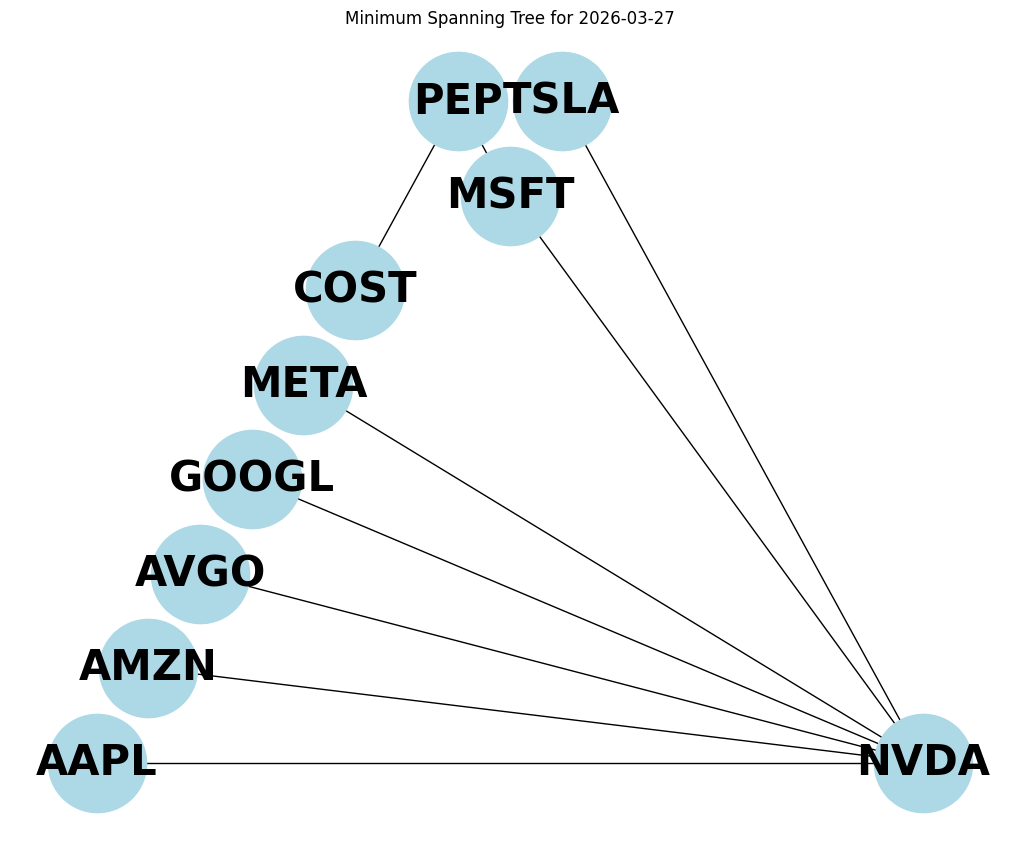

In [4]:

last_mst = df_trees['MST'].iloc[-1]
pos = nx.planar_layout(last_mst)  #positions for all nodes

plt.figure(figsize=(10, 8))
nx.draw(last_mst, pos, with_labels=True, node_color='lightblue', node_size=5000, font_size=30, font_weight='bold')
plt.title(f'Minimum Spanning Tree for {df_trees["Date"].iloc[-1].date()}')
plt.show()

We can see that NVDA is the medoid without any further analysis, which makes sense considering it's the largest cap stock out there and dictates a lot of the market movement.

SHOCK PROPAGATION SIMULATION

In [5]:
nvda_shock = contagion.simulate_shock(last_mst, 'NVDA', -0.10)

Shock event with magnitude -0.1 occurred!


In [6]:
sorted_impacts = dict(sorted(nvda_shock.items(), key=lambda x: x[1]))
print("Top Stocks impacted by an NVDA 10% drop:")

for ticker, val in list(sorted_impacts.items()):
    if ticker != 'NVDA':
        print(f"{ticker}: {val*100:.1f}%")

Top Stocks impacted by an NVDA 10% drop:
AVGO: -3.7%
TSLA: -3.5%
META: -3.4%
AMZN: -3.2%
GOOGL: -3.0%
AAPL: -2.6%
MSFT: -2.5%
COST: 0.0%
PEP: 0.2%


We've successfully simulated a shock contagion model on a small scale of stocks.